In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from astropy import constants as const 

In [33]:
#Testing out units
#And trying to match the papers results for phi metric at the surface r = R = 10 km
G = 7e-11  #N*m^2 / Kg^2  or m^3 / s^2 *kg
M = 2e30 # Kg
R = 1e4 #m
c_sqrd = (3e8) ** 2 #m/s
print( 'phi(R) in SI: ', np.log((1 - (2*G*M)/ (R*c_sqrd))) / 2 )
#Natural units 
G_nat = G * (1 / 8.19e5) * (1.8e-27)**2 * (1/.197e-15)**2
M_nat = M * 1 / 1.8e-27
R_nat = R * 1 / .197e-15 
print('Natural units ')
print('G = ', G_nat, "Gev^2")
print('M = ', M_nat, "Gev")
print('R = ', R_nat, "Gev^-1")
print( 'phi(R) natural units: ', np.log((1 - (2*G_nat*M_nat)/ (R_nat))) / 2 )

max_phi = np.log((1 - (2*G_nat*M_nat)/ (R_nat))) / 2

phi(R) in SI:  -0.18633764264258676
Natural units 
G =  7.135537553739518e-39 Gev^2
M =  1.1111111111111111e+57 Gev
R =  5.076142131979696e+19 Gev^-1
phi(R) natural units:  -0.18725798885165956


In [ ]:
def EoS( e_phi, B, gauss_conversion):
    P = np.zeros(len(e_phi))
    mu_n = 1# 10 * 1e-3  #chemical potential of neutron in Gev
    mu_D = -9.66e-27  / (1.6e-10 * gauss_conversion)# Magentic moment of a neutron in J/G
    m = 1  #mass of neutron & proton in Gev from paper
    e = .303 #unitless from paper
    pi = np.pi
    b_n = (6*pi**2)/ m**3
    mu_f = 1 #-53 * 1e-3 #Gev from paper
    b_cf = 3*pi**2 / (m)**3
    B_c = m**2/e
    
    #Eos for neutrons
    n_n = (e_phi**-3)/(6*pi) * ( ((mu_n + e_phi*mu_D*B)**2 - (m*e_phi)**2)**(3/2) +  ((mu_n - e_phi*mu_D*B)**2 - (m*e_phi)**2)**(3/2) )
    P_n = (e_phi * m**4 / (48 * pi**2) ) * ( np.sqrt( (b_n * n_n)**(2/3) + 1 ) * ( 2*b_n*n_n - 3*(b_n*n_n)**(1/3)) + 3*np.arcsinh( (b_n*n_n)**(1/3) ))
    
    #EoS for charged fermions
    n_cf = e_phi**-3 / (3*pi**2) * (mu_f**2 - e_phi**2 * (m**2 + 2*e*B*1))**(3/2) + (e*B*e_phi**-1 ) / (2*pi**2) * (mu_f**2 - (m*e_phi)**2)**(1/2)
    P_0 = (m**4*e_phi) / (24*pi**2) * ( np.sqrt((b_cf*n_cf)**(2/3) + 1) * (2*b_cf*n_cf - 3*(b_cf*n_cf)**(1/3)) + 3*np.arcsinh((b_cf*n_cf)**(1/3)) )
    P_B = (m**4*e_phi * B) / (12*pi**2*B_c) * ( 3*np.arcsinh((b_cf*n_cf)**(1/3)) - ( b_cf*n_cf + 3 *(b_cf*n_cf)**(1/3) ) / np.sqrt( (b_cf*n_cf)**(2/3) + 1) )
    P_cf = P_0 + P_B

    #Putting general Eos together based on radius/Phi value 

    #transition regions
    outer_inner = np.abs(max_phi) + 7e-4
    inner_core = np.abs(max_phi) +  .0065
    for i in range(len(e_phi)):
        if np.abs(e_phi[i]) <= np.abs(max_phi) and np.abs(e_phi[i]) <= outer_inner:
            #Outer Crust charged fermions
            P[i] = P_cf[i]
            
        elif np.abs(e_phi[i]) > outer_inner and np.abs(e_phi[i]) <= inner_core:
            #Inner Crust  neutron + charged fermions 
            P[i] = P_cf[i] + P_n[i] 
        
        elif np.abs(e_phi[i]) > inner_core:
            #Core pure neutron matter 
            P[i] = P_n[i] 
            
        else:
            P[i] = P_cf[i]
    
    
    return P
#Magnetic field in natrul units
# 1 Gauss = 1cm^-1/2 g^-1/2 s^-1  (.197e-12)**(1/2) *(1.8e-24)**(1/2) * (6.58e-25)
gauss_convert = 1e-4 * 5.28e-19 * 6.58e-25 / 1.8e-27
B_nat_14 = 1e14 * gauss_convert
B_nat_15 = 1e15 * gauss_convert

#these are the two phi values they ploted in the paper
#I think the phi that makes the most sense is -.3
phi_3 = np.linspace(max_phi,-.3,1000)
e_phi_3 = np.exp(phi_3)
phi_1 = np.linspace(max_phi,-.1,1000)
e_phi_1 = np.exp(phi_1)

EoS_B14_phi_3 = EoS(e_phi_3, B_nat_14, gauss_convert)
EoS_B14_phi_1 = EoS(e_phi_1, B_nat_14, gauss_convert)

EoS_B15_phi_3 = EoS(e_phi_3, B_nat_15, gauss_convert)
EoS_B15_phi_1 = EoS(e_phi_1, B_nat_15, gauss_convert)


        


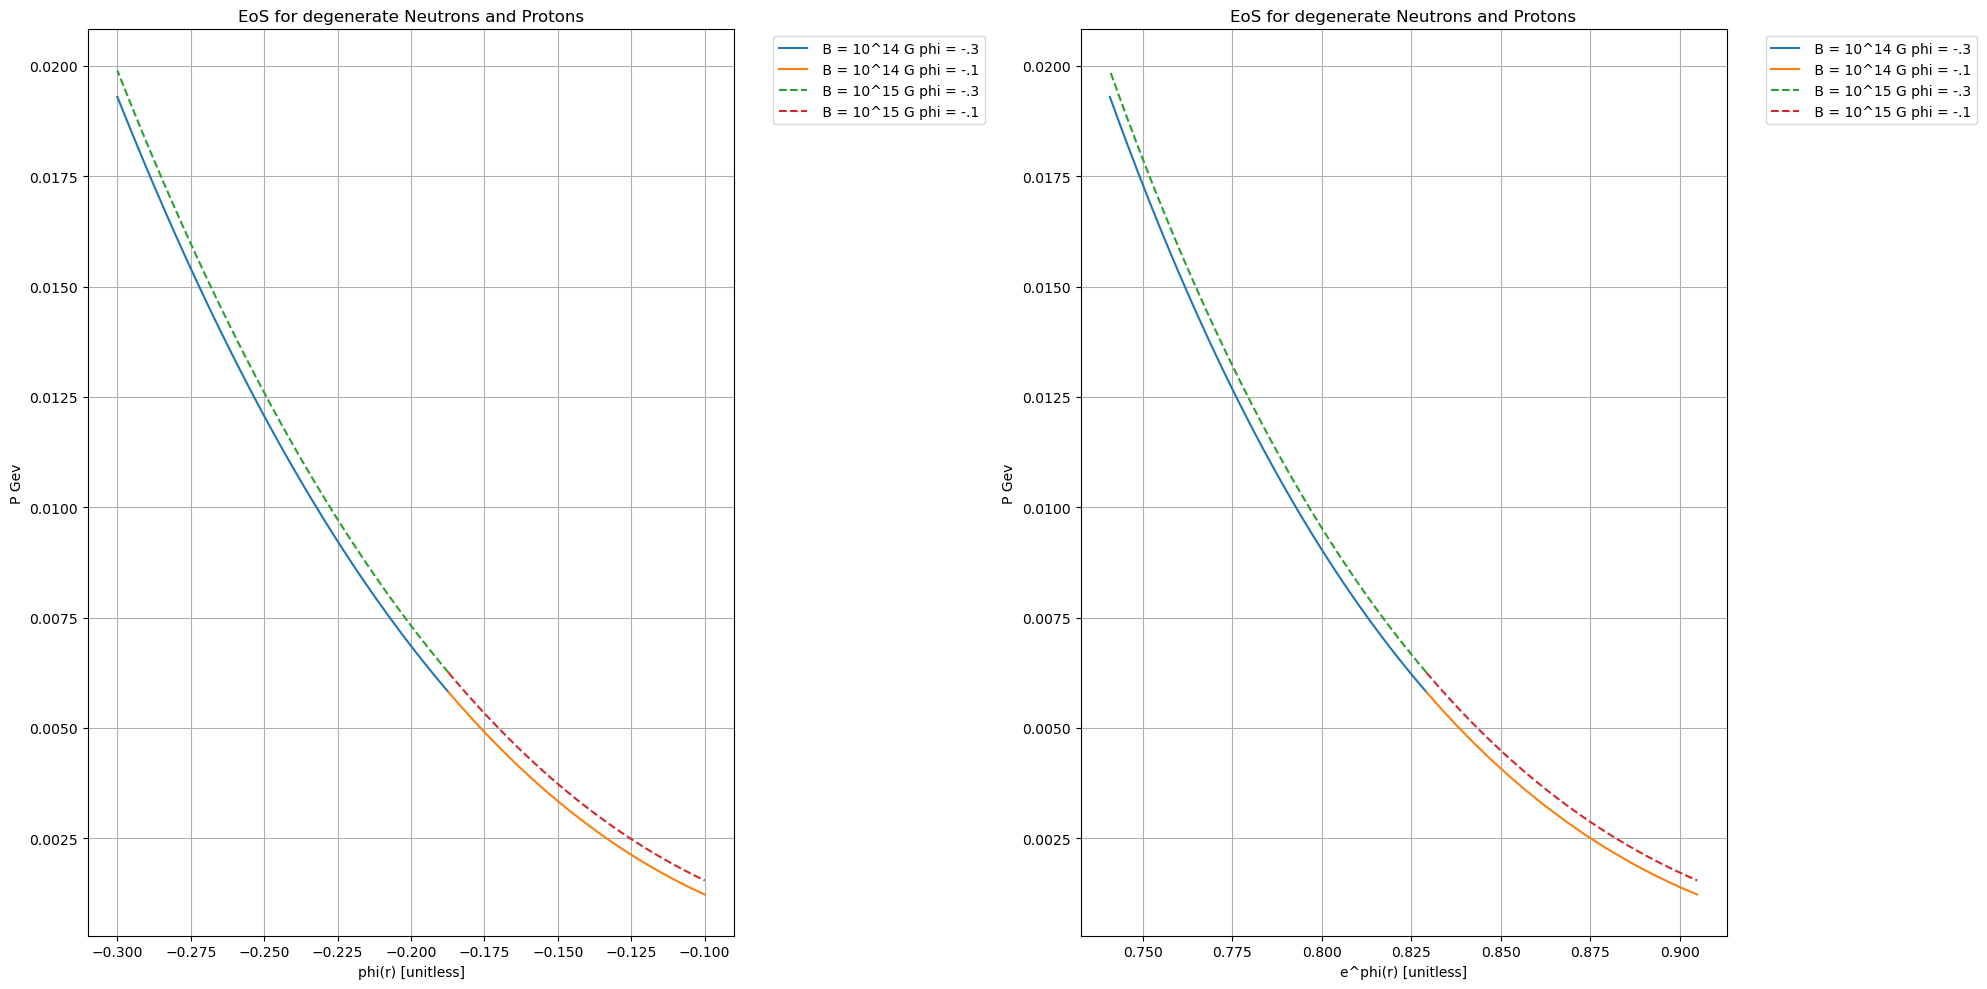

In [91]:
#print(EoS_B14)
fig, ax = plt.subplots(nrows=1, ncols= 2, figsize=(20, 10))

ax[0].plot(phi_3,EoS_B14_phi_3, label=' B = 10^14 G phi = -.3')
ax[0].plot(phi_1,EoS_B14_phi_1, label=' B = 10^14 G phi = -.1')

ax[0].plot(phi_3,EoS_B15_phi_3, linestyle = '--', label=' B = 10^15 G phi = -.3')
ax[0].plot(phi_1,EoS_B15_phi_1, linestyle = '--', label=' B = 10^15 G phi = -.1')



ax[0].set_xlabel('phi(r) [unitless]')
ax[0].set_ylabel('P Gev')
ax[0].set_title('EoS for degenerate Neutrons and Protons')
ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].grid()

ax[1].plot(e_phi_3,EoS_B14_phi_3, label=' B = 10^14 G phi = -.3')
ax[1].plot(e_phi_1,EoS_B14_phi_1, label=' B = 10^14 G phi = -.1')

ax[1].plot(e_phi_3,EoS_B15_phi_3, linestyle = '--', label=' B = 10^15 G phi = -.3')
ax[1].plot(e_phi_1,EoS_B15_phi_1, linestyle = '--', label=' B = 10^15 G phi = -.1')



ax[1].set_xlabel('e^phi(r) [unitless]')
ax[1].set_ylabel('P Gev')
ax[1].set_title('EoS for degenerate Neutrons and Protons')
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1].grid()

plt.tight_layout()
plt.show()